<a href="https://colab.research.google.com/github/Lopez-Max/MachineLearning/blob/main/Lopez_Machine_Learning_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ChatGPT was to debug and develop this code. This code was generated by ChatGPT with human-guided prompts and editing,

!wget "https://osf.io/xtyeb/download" -O ImageDataset.7z
!apt-get install -y p7zip-full
!7z x ImageDataset.7z -o./

--2025-10-19 03:15:53--  https://osf.io/xtyeb/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://osf.io/download/xtyeb [following]
--2025-10-19 03:15:53--  https://osf.io/download/xtyeb
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 PERMANENT REDIRECT
Location: https://osf.io/download/xtyeb/ [following]
--2025-10-19 03:15:53--  https://osf.io/download/xtyeb/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://files.osf.io/v1/resources/zq9pc/providers/osfstorage/683758ee499fdc186f539577 [following]
--2025-10-19 03:15:53--  https://files.osf.io/v1/resources/zq9pc/providers/osfstorage/683758ee499fdc186f539577
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP reques

✅ Loaded 3000 images total (1500 pre-CHF, 1500 post-CHF)
Feature vector size: 4096


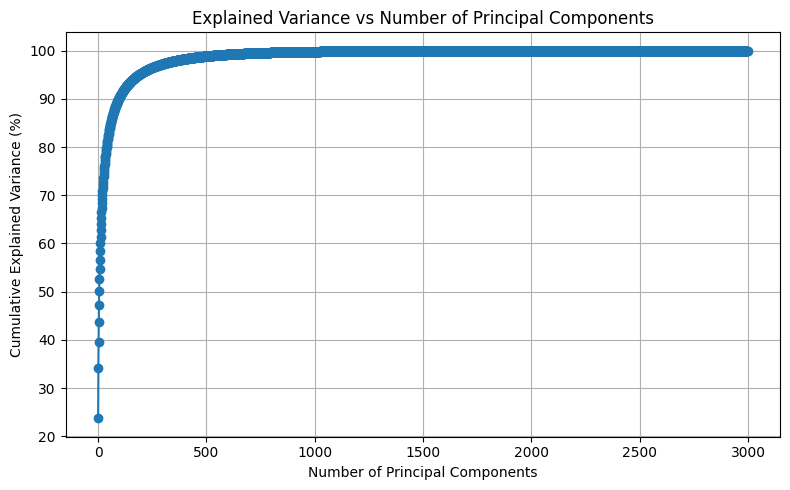

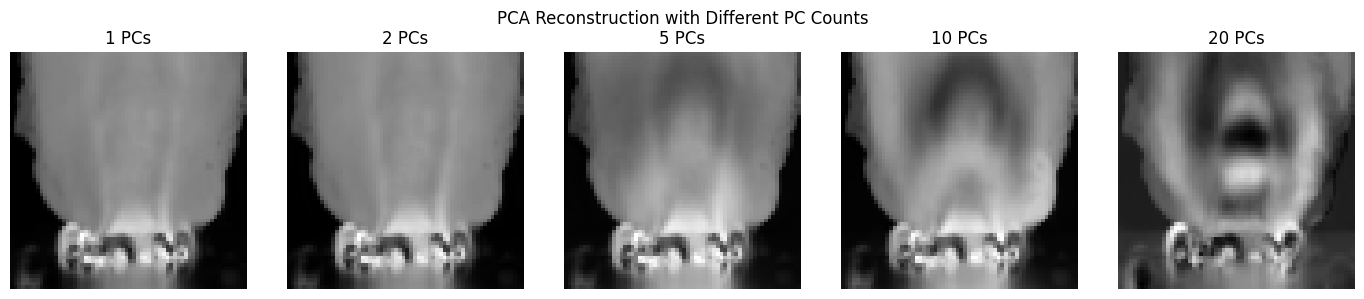

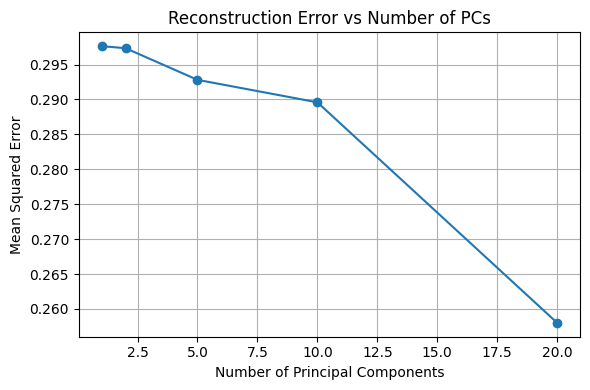


Applying t-SNE with perplexity=30...
Applying UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


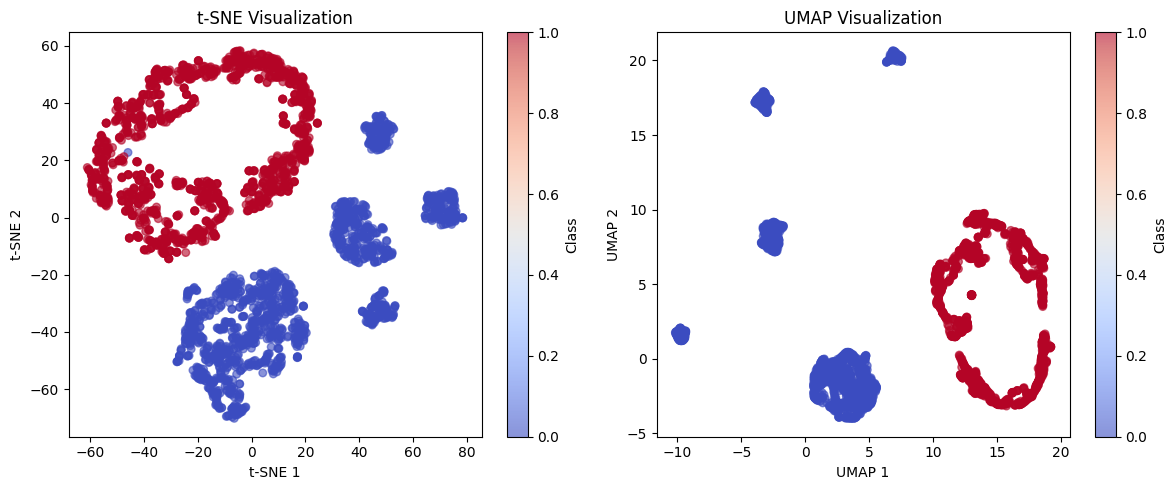


CLUSTERING EVALUATION METRICS
Number of clusters: 2
Number of PCs used: 20

Training Time: 0.0367 seconds
Testing Time: 0.0014 seconds

Silhouette Score: 0.4392  (Range: -1 to 1, higher is better)
Davies-Bouldin Index: 0.8368  (Lower is better)
Calinski-Harabasz Index: 1458.6671  (Higher is better)



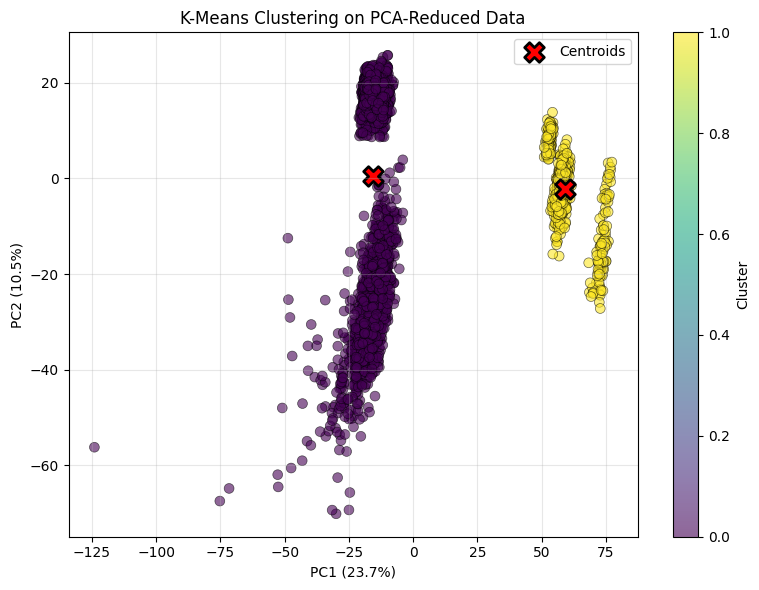

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from skimage.io import imread
from skimage.transform import resize
from sklearn.preprocessing import StandardScaler
import time

pre_chf_path = "ImageDataset/pre-CHF"
post_chf_path = "ImageDataset/post-CHF"

def load_images_from_folder(folder, label, img_size=(64, 64)):
    images, labels = [], []
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = imread(os.path.join(folder, filename))

                if len(img.shape) == 2:
                    img_gray = img
                else:
                    img = resize(img, img_size, anti_aliasing=True)
                    img_gray = np.mean(img, axis=-1)
                img_gray = resize(img_gray, img_size, anti_aliasing=True)
                images.append(img_gray.flatten())
                labels.append(label)
            except Exception as e:
                print(f"Error loading {filename}: {e}")
                continue
    return np.array(images), np.array(labels)


X_pre, y_pre = load_images_from_folder(pre_chf_path, label=0)
X_post, y_post = load_images_from_folder(post_chf_path, label=1)

if len(X_pre) == 0 or len(X_post) == 0:
    print("Warning: One or both folders are empty. Using dummy data for demonstration.")
    X_pre = np.random.randn(10, 4096)
    y_pre = np.zeros(10)
    X_post = np.random.randn(10, 4096)
    y_post = np.ones(10)

X = np.vstack((X_pre, X_post))
y = np.hstack((y_pre, y_post))

print(f"✅ Loaded {len(X)} images total ({len(X_pre)} pre-CHF, {len(X_post)} post-CHF)")
print(f"Feature vector size: {X.shape[1]}")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

max_components = min(X_scaled.shape[0] - 1, X_scaled.shape[1])
pca = PCA(n_components=max_components)
X_pca_full = pca.fit_transform(X_scaled)


explained_variance = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(8, 5))
plt.plot(explained_variance, marker='o')
plt.title("Explained Variance vs Number of Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


n_components = min(20, max_components)
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

rep_img_idx = 0
rep_img = X_scaled[rep_img_idx]

pc_counts = [1, 2, 5, 10, min(20, n_components)]
reconstructions = []
errors = []

for n in pc_counts:
    if n > max_components:
        continue
    pca_temp = PCA(n_components=n)
    X_temp = pca_temp.fit_transform(X_scaled)
    reconstructed = pca_temp.inverse_transform(X_temp[rep_img_idx])
    reconstructions.append(reconstructed)
    error = np.mean((rep_img - reconstructed) ** 2)
    errors.append(error)

fig, axes = plt.subplots(1, len(reconstructions), figsize=(14, 3))
if len(reconstructions) == 1:
    axes = [axes]
for i, (n, rec) in enumerate(zip(pc_counts[:len(reconstructions)], reconstructions)):
    axes[i].imshow(rec.reshape(64, 64), cmap='gray')
    axes[i].set_title(f"{n} PCs")
    axes[i].axis('off')
plt.suptitle("PCA Reconstruction with Different PC Counts")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(pc_counts[:len(errors)], errors, marker='o')
plt.title("Reconstruction Error vs Number of PCs")
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.tight_layout()
plt.show()

perplexity = min(30, (X_pca.shape[0] - 1) // 3)

print(f"\nApplying t-SNE with perplexity={perplexity}...")
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_tsne = tsne.fit_transform(X_pca)

print("Applying UMAP...")
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(15, X_pca.shape[0] - 1))
X_umap = umap_reducer.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', s=30, alpha=0.6)
axes[0].set_title("t-SNE Visualization")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

scatter2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', s=30, alpha=0.6)
axes[1].set_title("UMAP Visualization")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.colorbar(scatter1, ax=axes[0], label="Class")
plt.colorbar(scatter2, ax=axes[1], label="Class")
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

start_time = time.time()
kmeans.fit(X_pca)
end_time = time.time()
training_time = end_time - start_time

start_time = time.time()
clusters = kmeans.predict(X_pca)
end_time = time.time()
testing_time = end_time - start_time


silhouette = silhouette_score(X_pca, clusters)
db_index = davies_bouldin_score(X_pca, clusters)
ch_index = calinski_harabasz_score(X_pca, clusters)

print("\n" + "="*50)
print("CLUSTERING EVALUATION METRICS")
print("="*50)
print(f"Number of clusters: 2")
print(f"Number of PCs used: {n_components}")
print()
print(f"Training Time: {training_time:.4f} seconds")
print(f"Testing Time: {testing_time:.4f} seconds")
print()
print(f"Silhouette Score: {silhouette:.4f}  (Range: -1 to 1, higher is better)")
print(f"Davies-Bouldin Index: {db_index:.4f}  (Lower is better)")
print(f"Calinski-Harabasz Index: {ch_index:.4f}  (Higher is better)")
print("="*50 + "\n")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Centroids')
plt.title("K-Means Clustering on PCA-Reduced Data")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()